# Notebook 2b: Data Size, Data Diversity, and Class Imbalance

**Series:** Random Forests & Isolation Forests for Full-Stack Engineers  
**Prerequisites:** Notebooks 1 and 2  
**Author:** [Farty Bobo](https://fartybobo.com)  
**What you'll learn:** The three ways your training data can silently sabotage your model — and how to catch each one.

---

## The Software Engineering Analogy

You've got a service. It works beautifully in staging. You deploy it. It falls on its face in prod.

Why? Three usual suspects:

1. **Not enough test cases** — your staging tests covered 50 scenarios; prod hit the 51st.
2. **Test cases weren't diverse** — every staging test used the same small payload; prod sent a 10MB one.
3. **Test cases didn't reflect real traffic mix** — your load test was 50/50 reads/writes, but real traffic is 99% reads and 1% writes that happen to be the buggy path.

ML has the exact same three failure modes, and they have names:

| SWE version | ML version |
|---|---|
| Not enough test cases | **Insufficient training data** |
| Tests not diverse | **Low feature-space coverage** |
| Traffic mix mismatch | **Class imbalance** |

We're going to break each one on purpose, watch the model fail, then fix it.

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_classification, make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
)

pal = sns.color_palette('colorblind')
sns.set_palette(pal)

RNG_SEED = 42
print('Setup complete.')

Setup complete.


---

# Part 1: Data Size — Why "More Data" Is Usually the Right Answer

## The Intuition

A decision tree with no constraints will memorize whatever you give it. Give it 10 samples, it draws 10 tiny boxes around them and calls it a day. Perfect training accuracy. Useless on anything it hasn't seen.

This is **overfitting**, and the cleanest cure — before fancy regularization tricks — is more data. More samples mean the tree can't just memorize; it has to find patterns that *actually generalize*.

We're going to prove this empirically with a **learning curve**: train the same model on progressively larger subsets of the same training data, and watch what happens to train vs. test accuracy.

**What a healthy learning curve looks like:**
- **Tiny data:** train accuracy ≈ 100%, test accuracy is bad → huge gap → overfitting
- **More data:** test accuracy climbs, train accuracy drops slightly as the model stops memorizing
- **Enough data:** the two curves converge → the model is learning the real signal
- **Diminishing returns:** adding more doesn't help much → you've saturated what this model can learn from this feature set

That last point is critical. If your learning curve has plateaued, **more data won't save you** — you need a better model or better features.

## The Experiment

We'll build a moderately hard synthetic classification problem (20 features, 3 classes, some noise) and train a decision tree on increasing fractions of the data.

In [2]:
# A dataset that's hard enough that more data actually matters.
# 20 features, only 8 of which are informative, 3 classes, some redundancy.
X_all, y_all = make_classification(
    n_samples=5_000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_classes=3,
    n_clusters_per_class=2,
    class_sep=1.0,
    flip_y=0.03,          # 3% label noise — realistic
    random_state=RNG_SEED,
)

# Hold out a fixed test set — we'll evaluate every model against the SAME test data
# so differences come from training size alone, not lucky/unlucky splits.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_all, y_all, test_size=0.3, random_state=RNG_SEED, stratify=y_all,
)

print(f'Full training pool:  {len(X_train_full):,} samples')
print(f'Held-out test set:   {len(X_test):,} samples')
print(f'Class distribution (train): {np.bincount(y_train_full)}')

Full training pool:  3,500 samples
Held-out test set:   1,500 samples
Class distribution (train): [1159 1175 1166]


In [3]:
# Train the same unconstrained decision tree on progressively more data.
# Unconstrained = no max_depth, no min_samples — the tree will overfit if it can.

sizes = [20, 50, 100, 250, 500, 1000, 2000, 3500]
train_scores = []
test_scores = []

rng = np.random.default_rng(RNG_SEED)

for n in sizes:
    # Sample a stratified-ish subset from the training pool.
    # We use the same seed every iteration so smaller sets are PREFIXES of larger ones
    # (this keeps the curve monotonic-ish and interpretable).
    idx = rng.permutation(len(X_train_full))[:n]
    X_sub = X_train_full[idx]
    y_sub = y_train_full[idx]

    clf = DecisionTreeClassifier(random_state=RNG_SEED)
    clf.fit(X_sub, y_sub)

    train_scores.append(accuracy_score(y_sub, clf.predict(X_sub)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

learning_curve = pd.DataFrame({
    'n_train': sizes,
    'train_acc': train_scores,
    'test_acc': test_scores,
    'gap': np.array(train_scores) - np.array(test_scores),
})
learning_curve.round(3)

,n_train,train_acc,test_acc,gap
0,20,1.0,0.443,0.557
1,50,1.0,0.579,0.421
2,100,1.0,0.533,0.467
3,250,1.0,0.612,0.388
4,500,1.0,0.641,0.359
5,1000,1.0,0.711,0.289
6,2000,1.0,0.741,0.259
7,3500,1.0,0.765,0.235


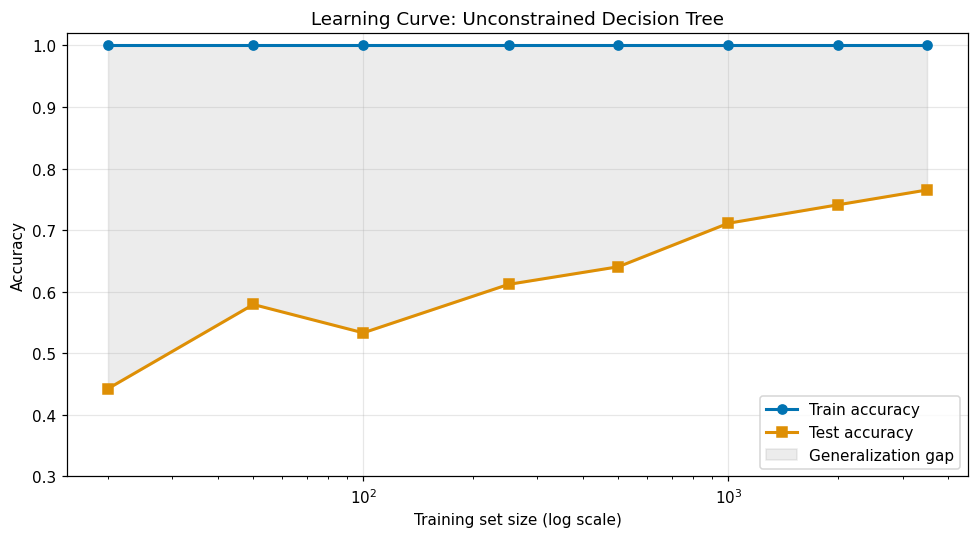

In [4]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=110)

ax.plot(sizes, train_scores, 'o-', lw=2, label='Train accuracy', color=pal[0])
ax.plot(sizes, test_scores,  's-', lw=2, label='Test accuracy',  color=pal[1])
ax.fill_between(sizes, train_scores, test_scores, alpha=0.15, color='gray', label='Generalization gap')

ax.set_xscale('log')
ax.set_xlabel('Training set size (log scale)')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curve: Unconstrained Decision Tree')
ax.set_ylim(0.3, 1.02)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### What to Look For

- **Left side of the chart (small n):** train accuracy is pegged near 100%, test accuracy is much lower. The gray gap is huge. The tree has memorized the training samples — it's a lookup table, not a classifier.
- **Moving right:** test accuracy climbs steadily, train accuracy dips slightly or holds, and the gap narrows. This is the model *actually learning*.
- **Right side:** both curves flatten. Adding more data gives you pennies of accuracy. You've hit the ceiling for this model + feature set.

### The Practical Takeaway

**Before reaching for fancier models, check your learning curve.** If your test accuracy is still climbing at your current data size, collecting more data is the single highest-leverage thing you can do. If it's plateaued, no amount of extra data will help — time to engineer better features or switch models.

---

# Part 2: Data Diversity — Coverage of the Feature Space

## The Intuition

"We have 10,000 training samples" sounds great until you realize they're all from one region of the input space.

Decision trees (and most models) can only learn what they've seen. Ask a tree about a region of feature space that had zero training examples and it'll give you an answer — but that answer is whatever the nearest-in-tree-structure leaf happens to say. Pure guesswork dressed up as a prediction.

The software analogy: you have 10,000 unit tests but they all exercise the happy path. Your coverage report says 40% and you wonder why prod keeps crashing. Size isn't the problem. **Diversity** is.

## The Experiment

We'll use the classic `make_moons` 2D dataset — two interlocking crescents — and compare two training regimes with the **same number of samples**:

- **Narrow training data:** samples only from the left half of the feature space.
- **Broad training data:** samples from the full feature space.

Both models get tested on the full distribution. Watch what happens.

In [5]:
# Generate a big pool of 2D moons data with noise.
X_moons, y_moons = make_moons(n_samples=4_000, noise=0.25, random_state=RNG_SEED)

# Test set: sampled from the FULL distribution. This is "production".
X_test_m, y_test_m = make_moons(n_samples=1_000, noise=0.25, random_state=RNG_SEED + 1)

# --- Narrow training: only keep samples where x0 < median ---
# (Pretend this is 'we only collected data from one cohort / one region / one day')
median_x0 = np.median(X_moons[:, 0])
narrow_mask = X_moons[:, 0] < median_x0
X_narrow = X_moons[narrow_mask]
y_narrow = y_moons[narrow_mask]

# --- Broad training: random subsample matched to the narrow size ---
n_match = len(X_narrow)
rng_d = np.random.default_rng(RNG_SEED)
broad_idx = rng_d.choice(len(X_moons), size=n_match, replace=False)
X_broad = X_moons[broad_idx]
y_broad = y_moons[broad_idx]

print(f'Narrow training set: {len(X_narrow):,} samples (only left half of feature space)')
print(f'Broad  training set: {len(X_broad):,} samples (full feature space)')
print('Same size. Different coverage.')

Narrow training set: 2,000 samples (only left half of feature space)
Broad  training set: 2,000 samples (full feature space)
Same size. Different coverage.


In [6]:
# Train two trees with identical hyperparameters.
tree_narrow = DecisionTreeClassifier(max_depth=6, random_state=RNG_SEED).fit(X_narrow, y_narrow)
tree_broad  = DecisionTreeClassifier(max_depth=6, random_state=RNG_SEED).fit(X_broad,  y_broad)

acc_narrow = accuracy_score(y_test_m, tree_narrow.predict(X_test_m))
acc_broad  = accuracy_score(y_test_m, tree_broad.predict(X_test_m))

print(f'Narrow-training tree → test accuracy: {acc_narrow:.3f}')
print(f'Broad-training  tree → test accuracy: {acc_broad:.3f}')
print(f'Accuracy gap: {acc_broad - acc_narrow:+.3f}')

Narrow-training tree → test accuracy: 0.842
Broad-training  tree → test accuracy: 0.932
Accuracy gap: +0.090


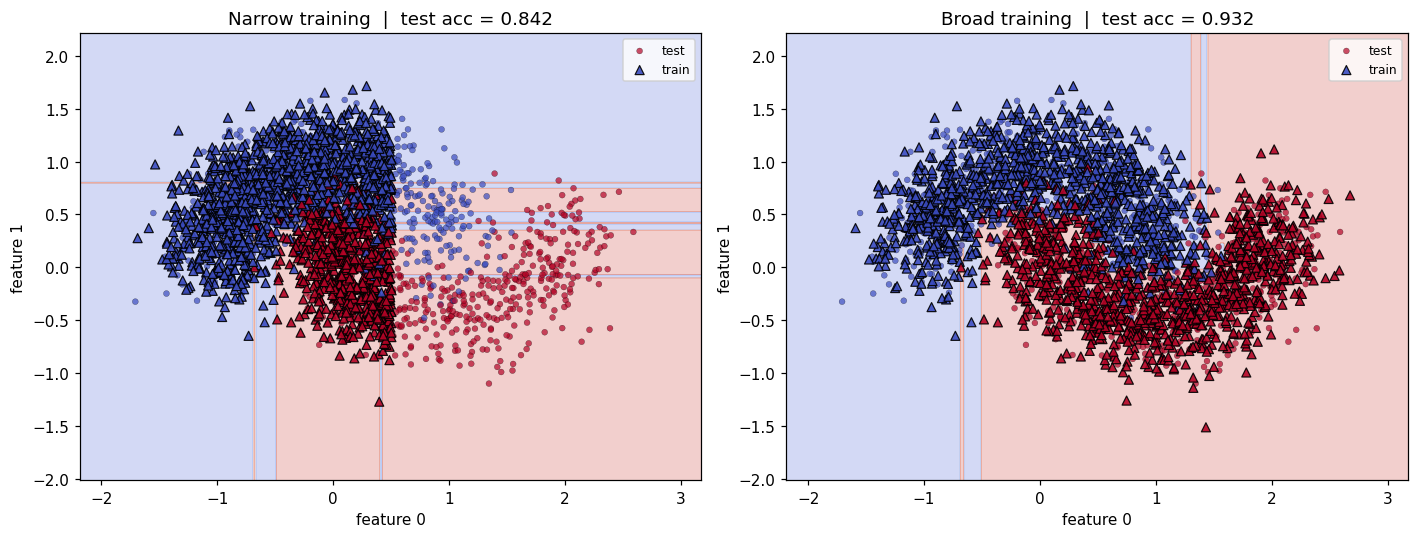

In [7]:
# Visualize decision boundaries over the FULL feature space.
# This is what makes coverage failures obvious.

def plot_boundary(ax, model, X_tr, y_tr, X_te, y_te, title):
    x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
    y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.scatter(X_te[:, 0], X_te[:, 1], c=y_te, cmap='coolwarm',
               s=15, alpha=0.7, edgecolors='k', linewidths=0.2, label='test')
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap='coolwarm',
               s=35, alpha=0.9, edgecolors='black', linewidths=0.8, marker='^', label='train')
    ax.set_title(title)
    ax.set_xlabel('feature 0')
    ax.set_ylabel('feature 1')
    ax.legend(loc='upper right', fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=110)
plot_boundary(axes[0], tree_narrow, X_narrow, y_narrow, X_test_m, y_test_m,
              f'Narrow training  |  test acc = {acc_narrow:.3f}')
plot_boundary(axes[1], tree_broad,  X_broad,  y_broad,  X_test_m, y_test_m,
              f'Broad training  |  test acc = {acc_broad:.3f}')
plt.tight_layout()
plt.show()

### What to Look For

Triangles are training points, circles are test points, colored regions are the model's decision surface.

- **Narrow plot:** the training points all live on the left. The decision boundary on the left is sensible, but on the **right half** — where no training data ever lived — the model extends whatever pattern it happened to find in the rightmost training samples. That extrapolation is a coin flip. Test points on the right get misclassified in droves.
- **Broad plot:** training points cover the full space. The decision boundary actually follows the two moons. Test accuracy is noticeably higher despite using the same number of training samples.

### The Practical Takeaway

**Sample count is a vanity metric. Feature-space coverage is the real one.** Before you ship a model, check how your training distribution compares to your production input distribution. Tools for this:

- Plot histograms of each feature in train vs. prod.
- For high-dimensional data: UMAP or PCA projection of train vs. prod side-by-side.
- Statistical drift tests (KS test, PSI, etc.) per feature.

If your prod data lives somewhere your training data doesn't, your model is hallucinating in that region. No algorithm saves you from this.

---

# Part 3: Class Imbalance — The Accuracy Paradox

## The Intuition

You're building a fraud detector. 99% of transactions are legitimate, 1% are fraud.

You train a classifier. It reports **99% accuracy**. Ship it! 🎉

Except your model learned exactly one rule: **predict 'not fraud' every time.** That gets it 99% right, because 99% of things aren't fraud. It catches zero actual fraud cases. It's worse than useless — it's a 99%-accurate rubber stamp.

This is the **accuracy paradox**, and it's why `accuracy_score` is a lying metric on imbalanced data.

**The SWE analogy:** your health check endpoint returns `{"status": "ok"}` on every request, including when the database is down. It passes 99.9% of its 'tests'. That's not a passing grade. That's a bug that happens to look good on a dashboard.

## What To Measure Instead

For imbalanced problems, look at the **minority class** specifically:

- **Precision** = of the items we flagged as minority, how many actually were? (Minimize false alarms.)
- **Recall** = of the actual minority items, how many did we catch? (Minimize missed cases.)
- **F1** = harmonic mean of the two. Penalizes ignoring either one.
- **Confusion matrix** = don't skip this. Just look at the damn thing.

## The Experiment

We'll build an imbalanced 95/5 dataset, train a baseline classifier, and then compare three standard remedies:

1. **`class_weight='balanced'`** — tell sklearn to weight errors on the minority class more heavily during training.
2. **Random undersampling** — throw away majority samples until classes are balanced.
3. **Random oversampling** — duplicate minority samples until classes are balanced.

(We're skipping SMOTE to stay pure-sklearn. If you want it, `pip install imbalanced-learn`.)

In [8]:
# Build a 95/5 imbalanced binary classification problem.
X_imb, y_imb = make_classification(
    n_samples=10_000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    weights=[0.95, 0.05],    # <-- the imbalance
    flip_y=0.02,
    class_sep=0.8,
    random_state=RNG_SEED,
)

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=RNG_SEED, stratify=y_imb,
)

print(f'Training set:   {len(X_tr_i):,} samples')
print(f'  Majority (0): {(y_tr_i == 0).sum():,}  ({(y_tr_i==0).mean()*100:.1f}%)')
print(f'  Minority (1): {(y_tr_i == 1).sum():,}  ({(y_tr_i==1).mean()*100:.1f}%)')
print()
print(f'Test set:       {len(X_te_i):,} samples')
print(f'  Majority (0): {(y_te_i == 0).sum():,}')
print(f'  Minority (1): {(y_te_i == 1).sum():,}')

Training set:   7,000 samples
  Majority (0): 6,586  (94.1%)
  Minority (1): 414  (5.9%)

Test set:       3,000 samples
  Majority (0): 2,823
  Minority (1): 177


In [9]:
# Helper: train a random forest and return a dict of minority-class metrics.
def evaluate(name, clf, X_tr, y_tr, X_te, y_te):
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    return {
        'strategy':  name,
        'accuracy':  accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, pos_label=1, zero_division=0),
        'recall':    recall_score(y_te, y_pred, pos_label=1, zero_division=0),
        'f1':        f1_score(y_te, y_pred, pos_label=1, zero_division=0),
        'confusion': confusion_matrix(y_te, y_pred),
        'y_pred':    y_pred,
    }

# --- Strategy 1: Baseline (do nothing) ---
results = []
results.append(evaluate(
    'Baseline',
    RandomForestClassifier(n_estimators=100, random_state=RNG_SEED),
    X_tr_i, y_tr_i, X_te_i, y_te_i,
))

# --- Strategy 2: class_weight='balanced' ---
results.append(evaluate(
    'class_weight=balanced',
    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RNG_SEED),
    X_tr_i, y_tr_i, X_te_i, y_te_i,
))

# --- Strategy 3: Random undersampling of majority class ---
rng_u = np.random.default_rng(RNG_SEED)
minority_mask = (y_tr_i == 1)
majority_mask = (y_tr_i == 0)
n_minority = minority_mask.sum()

majority_idx = np.where(majority_mask)[0]
under_idx = rng_u.choice(majority_idx, size=n_minority, replace=False)
keep_idx = np.concatenate([under_idx, np.where(minority_mask)[0]])

X_tr_under = X_tr_i[keep_idx]
y_tr_under = y_tr_i[keep_idx]

results.append(evaluate(
    'Undersample majority',
    RandomForestClassifier(n_estimators=100, random_state=RNG_SEED),
    X_tr_under, y_tr_under, X_te_i, y_te_i,
))

# --- Strategy 4: Random oversampling of minority class ---
rng_o = np.random.default_rng(RNG_SEED)
n_majority = majority_mask.sum()
minority_idx = np.where(minority_mask)[0]
over_idx = rng_o.choice(minority_idx, size=n_majority, replace=True)  # with replacement = duplication
keep_idx = np.concatenate([np.where(majority_mask)[0], over_idx])

X_tr_over = X_tr_i[keep_idx]
y_tr_over = y_tr_i[keep_idx]

results.append(evaluate(
    'Oversample minority',
    RandomForestClassifier(n_estimators=100, random_state=RNG_SEED),
    X_tr_over, y_tr_over, X_te_i, y_te_i,
))

summary = pd.DataFrame([{k: v for k, v in r.items() if k not in ('confusion', 'y_pred')} for r in results])
summary.round(3)

,strategy,accuracy,precision,recall,f1
0,Baseline,0.960,0.889,0.362,0.514
1,class_weight=balanced,0.958,0.906,0.328,0.481
2,Undersample majority,0.846,0.248,0.791,0.378
3,Oversample minority,0.963,0.849,0.446,0.585


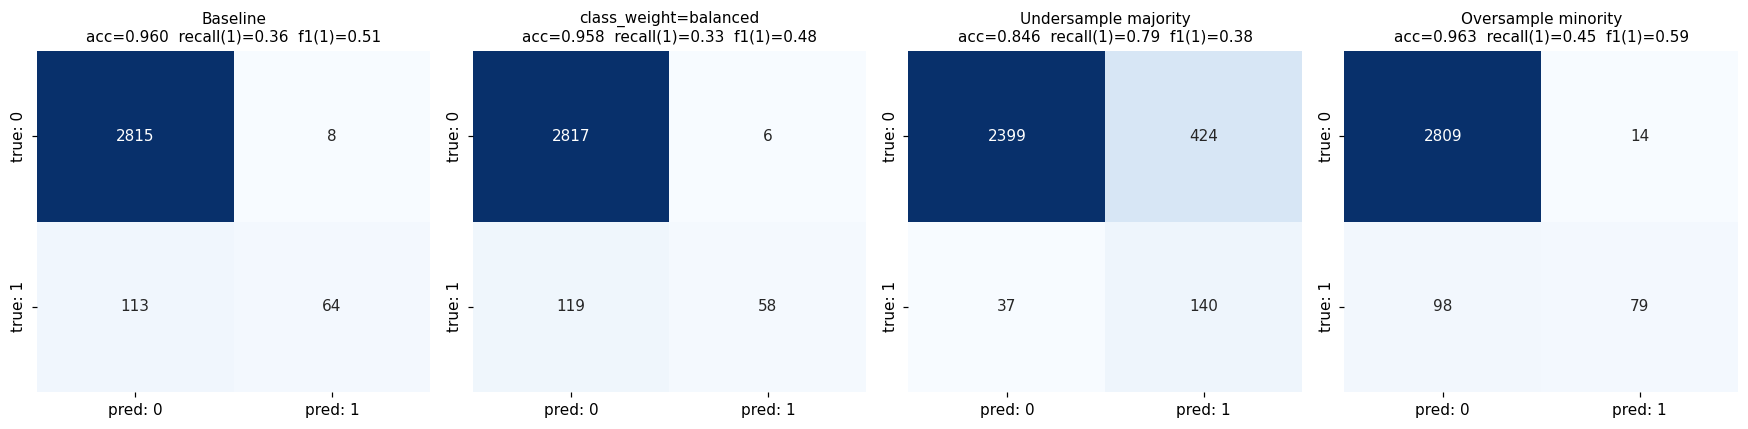

In [10]:
# Plot confusion matrices side-by-side so the accuracy paradox is visible.
fig, axes = plt.subplots(1, 4, figsize=(16, 4), dpi=110)

for ax, r in zip(axes, results):
    cm = r['confusion']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['pred: 0', 'pred: 1'],
                yticklabels=['true: 0', 'true: 1'], ax=ax)
    ax.set_title(f"{r['strategy']}\nacc={r['accuracy']:.3f}  recall(1)={r['recall']:.2f}  f1(1)={r['f1']:.2f}",
                 fontsize=10)

plt.tight_layout()
plt.show()

### What to Look For

Look at the **Baseline** column first:

- Accuracy looks great (~95%+). Champagne emoji.
- But look at the bottom row of the confusion matrix: a huge chunk of actual class-1 samples got predicted as class 0. **Recall on the minority class is the real story**, and it's bad.
- The model learned the lazy heuristic: "guess majority, be right most of the time."

Now compare the three remedies:

- **`class_weight='balanced'`**: usually the cheapest fix. No data manipulation — you tell the tree that a wrong call on the minority class *hurts more* during training. Recall shoots up; overall accuracy drops a bit because you're now making more false alarms. That's the tradeoff.
- **Undersampling**: throws away real data from the majority class. Balances the set, but you lose information. Good when the majority class is massive and redundant; bad when your dataset is small to begin with.
- **Oversampling** (duplication): every minority sample gets cloned. No data is lost, but trees can overfit to duplicated rows. SMOTE (synthetic minority oversampling) is the smarter cousin of this — it generates new *interpolated* minority samples instead of xeroxing existing ones.

There is no single "best" strategy — it depends on dataset size, how expensive false negatives vs. false positives are in your application, and how noisy your minority labels are.

### The Practical Takeaway

1. **Stratify your train/test splits** (`stratify=y`). Always. Otherwise your test set's class balance is a random variable.
2. **Never trust `accuracy` alone on imbalanced data.** Print the confusion matrix. Report precision, recall, and F1 for the minority class.
3. **Pick your metric based on cost.** If a missed fraud costs $10,000 and a false alarm costs 30 seconds of human review — optimize for recall. If the opposite — optimize for precision.
4. **Start with `class_weight='balanced'`**. It's one keyword argument. If it's not enough, then reach for resampling.

---

# Summary

Three ways data silently breaks your model, and three diagnostics to catch each:

| Problem | Symptom | Diagnostic | First fix |
|---|---|---|---|
| **Too little data** | Huge train/test gap; test accuracy still climbing | Learning curve | Collect more data, or regularize (max_depth, pruning) |
| **Low diversity** | Great on test set, terrible in prod | Feature distribution comparison (train vs. prod) | Targeted data collection; augmentation |
| **Class imbalance** | High accuracy, near-zero recall on minority | Confusion matrix; per-class precision/recall/F1 | `class_weight='balanced'`; then resampling / SMOTE |

The common thread: **don't trust a single aggregate metric.** Look at the curve. Look at the distribution. Look at the confusion matrix. Every silent data problem in ML is visible if you draw the right picture.

## What's Next

Notebook 3 moves on to **Random Forests** — what happens when you train not one tree but a whole damn forest, average their votes, and why that fixes a lot (though not all) of the problems above.